# Semi Gradient n-step Sarsa

In [1]:
from algorithms.sgns_sarsa.n_step_sarsa import SGNStepSARSA, Config
from mdp.base_config import BaseConfig
import numpy as np
import matplotlib.pyplot as plt
from mdp.cats_v_monsters.cats_vs_monsters import CatsVMonstersMDP
from algorithms.value_iteration.value_iteration import ValueIteration
from mdp.mdp_utils import display_value_function, display_policy, max_norm_error

base_config = BaseConfig(42)
from itertools import product
from tqdm.notebook import tqdm

%load_ext autoreload
%autoreload 2

## Cats vs Monsters MDP

### Find the optimal value function and policy using Value Iteration

In [2]:
optimal_mdp = CatsVMonstersMDP()
optimal_vi = ValueIteration(mdp=optimal_mdp)
optimal_rh = optimal_vi.run_value_iteration()
optimal_vf, optimal_policy = optimal_rh[len(optimal_rh)]
print("Optimal Value Function:")
display_value_function(optimal_mdp, optimal_vf)
print("Optimal Policy:")
display_policy(optimal_mdp, optimal_policy)

Optimal Value Function:
2.6638	2.9969	2.8117	3.6671	4.8497	
2.9713	3.5101	4.0819	4.8497	7.1648	
2.5936	0.0000	0.0000	0.0000	8.4687	
2.0992	1.0849	0.0000	8.6097	9.5269	
1.0849	4.9465	8.4687	9.5269	0.0000	
Optimal Policy:
→	↓	←	↓	↓	
→	→	→	→	↓	
↑	F	F	F	↓	
↑	←	F	↓	↓	
↑	→	→	→	G	


In [3]:
cvm = CatsVMonstersMDP()
config = Config(q_init_choice='zeroes', optimistic_value=10, epsilon=0.3)
sarsa = SGNStepSARSA(cvm, optimal_vf=optimal_vf, gamma=0.925)

In [4]:
reward = sarsa.run_episode(alpha=0.01, n_steps=2)
print(f"Total reward in one episode: {reward}")

Total reward in one episode: 0


In [5]:
points_metadata, mse_metadata, _ = sarsa.run_n_times(num_times=20, num_episodes=10000, alpha=0.03, n_steps=3)

20 Independent Runs:   0%|          | 0/20 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

...

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

In [6]:
print(points_metadata.shape)
mean_steps = np.mean(points_metadata, axis=0)
print(mean_steps.shape)

(20, 10000)
(10000,)


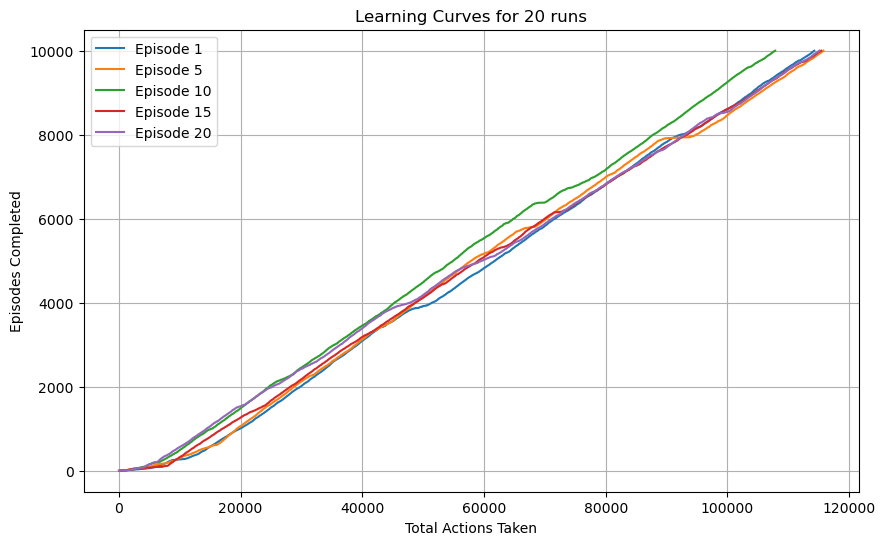

In [7]:
episodes = np.arange(1, mean_steps.shape[0] + 1)
plt.figure(figsize=(10, 6))
for run in [0, 4, 9, 14, 19]:
    plt.plot(points_metadata[run], episodes, label=f"Episode {run+1}")
plt.xlabel("Total Actions Taken")
plt.ylabel("Episodes Completed")
plt.title("Learning Curves for 20 runs")
plt.grid(True)
plt.legend()
plt.show()

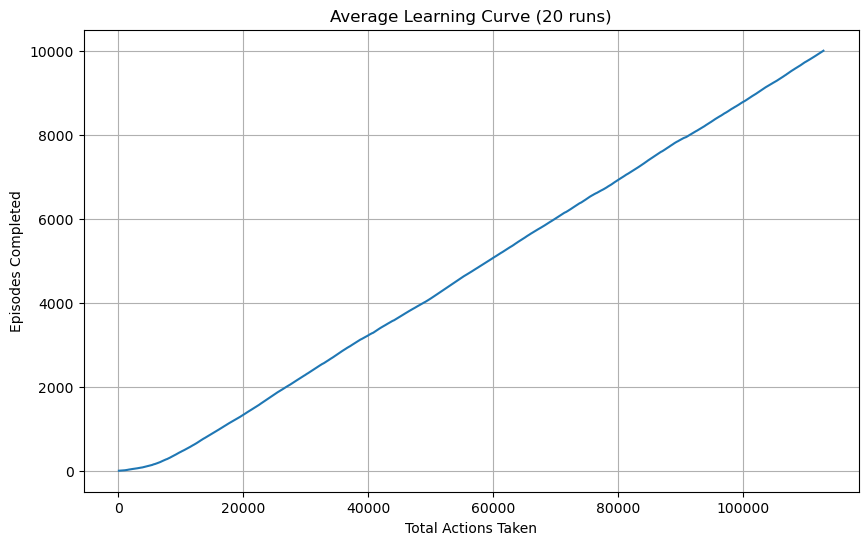

In [8]:
plt.figure(figsize=(10, 6))
episodes = np.arange(1, mean_steps.shape[0] + 1)
plt.plot(mean_steps, episodes)
plt.xlabel("Total Actions Taken")
plt.ylabel("Episodes Completed")
plt.title("Average Learning Curve (20 runs)")
plt.grid(True)
plt.show()

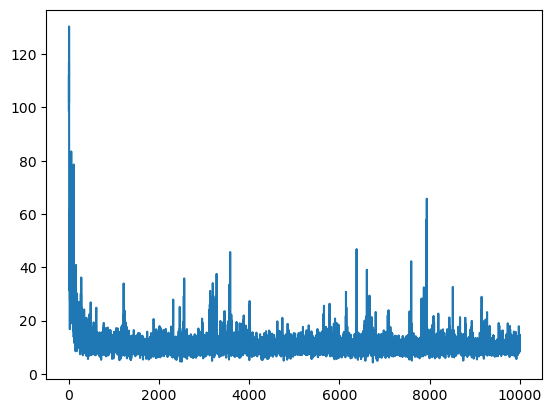

In [9]:
episode_lengths = np.diff(mean_steps)
plt.plot(episode_lengths)
plt.show()

In [10]:
print(mse_metadata.shape)
mean_mse = np.mean(mse_metadata, axis=0)
print(mean_mse.shape)

(20, 10000)
(10000,)


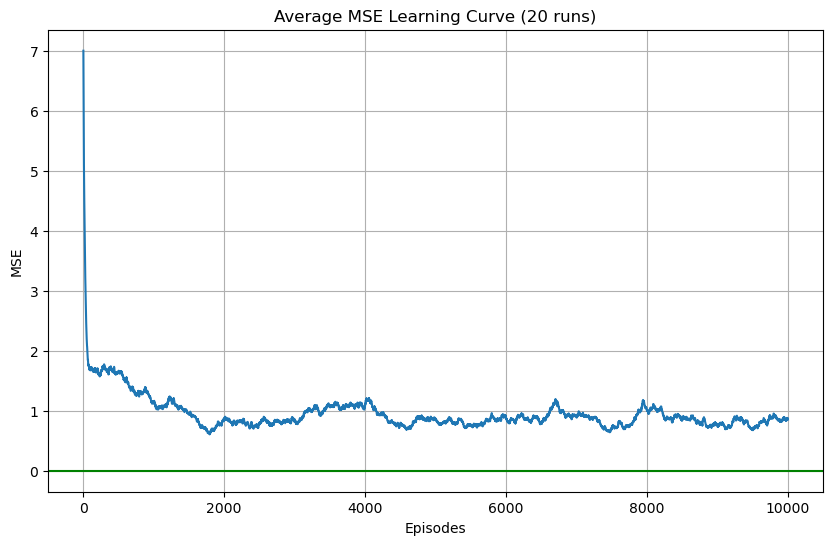

In [11]:
plt.figure(figsize=(10, 6))
episodes = np.arange(1, mse_metadata.shape[1] + 1)
plt.plot(episodes, mean_mse)
plt.axhline(y=0, color='g', label='0 MSE')
plt.xlabel("Episodes")
plt.ylabel("MSE")
plt.title("Average MSE Learning Curve (20 runs)")
plt.grid(True)
plt.show()

In [12]:
alpha_values = [0.01, 0.05, 0.07, 0.09]
n_step_values = [1, 3, 5]
cvm = CatsVMonstersMDP()
config = Config(q_init_choice='zeroes', epsilon=0.3)
results = {}
hp_combos = list(product(alpha_values, n_step_values))
for alpha, n_steps in tqdm(hp_combos, desc="Running hyperparameter combinations"):
    print(f"Running for alpha={alpha}, n_steps={n_steps}")
    sarsa = SGNStepSARSA(cvm, optimal_vf=optimal_vf, gamma=0.925)
    points_metadata, mse_metadata, _ = sarsa.run_n_times(num_times=10, num_episodes=7000, alpha=alpha, n_steps=n_steps)
    mean_steps = np.mean(points_metadata, axis=0)
    mean_mse = np.mean(mse_metadata, axis=0)
    results[(alpha, n_steps)] = {
        "mean_steps": mean_steps,
        "mean_mse": mean_mse
    }

Running hyperparameter combinations:   0%|          | 0/12 [00:00<?, ?it/s]

Running for alpha=0.01, n_steps=1


10 Independent Runs:   0%|          | 0/10 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/7000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/7000 [00:00<?, ?it/s]

...

Running SARSA Episodes:   0%|          | 0/7000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/7000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/7000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/7000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/7000 [00:00<?, ?it/s]

In [13]:
# Print MSE Stats - mean, median and std for each alpha and n_steps as tabulate
from tabulate import tabulate
mse_stats = []
for (alpha, n_steps), data in results.items():
    mean_mse = np.mean(data["mean_mse"])
    median_mse = np.median(data["mean_mse"])
    std_mse = np.std(data["mean_mse"])
    max_mse = np.max(data["mean_mse"])
    min_mse = np.min(data["mean_mse"])
    mse_stats.append([alpha, n_steps, mean_mse, median_mse, std_mse, max_mse, min_mse])
print(tabulate(mse_stats, headers=["Alpha", "N Steps", "Mean MSE", "Median MSE", "Std MSE", "Max MSE", "Min MSE"], tablefmt="grid"))

+---------+-----------+------------+--------------+-----------+-----------+-----------+
|   Alpha |   N Steps |   Mean MSE |   Median MSE |   Std MSE |   Max MSE |   Min MSE |
+=========+===========+============+==============+===========+===========+===========+
|    0.01 |         1 |   0.689457 |     0.440817 |  0.801996 |   7.13052 |  0.35282  |
+---------+-----------+------------+--------------+-----------+-----------+-----------+
|    0.01 |         3 |   0.830313 |     0.718201 |  0.525413 |   7.09087 |  0.555363 |
+---------+-----------+------------+--------------+-----------+-----------+-----------+
|    0.01 |         5 |   0.922469 |     0.848449 |  0.52175  |   7.07861 |  0.555305 |
+---------+-----------+------------+--------------+-----------+-----------+-----------+
|    0.05 |         1 |   0.763669 |     0.717525 |  0.3574   |   7.01732 |  0.496845 |
+---------+-----------+------------+--------------+-----------+-----------+-----------+
|    0.05 |         3 |   1.2586

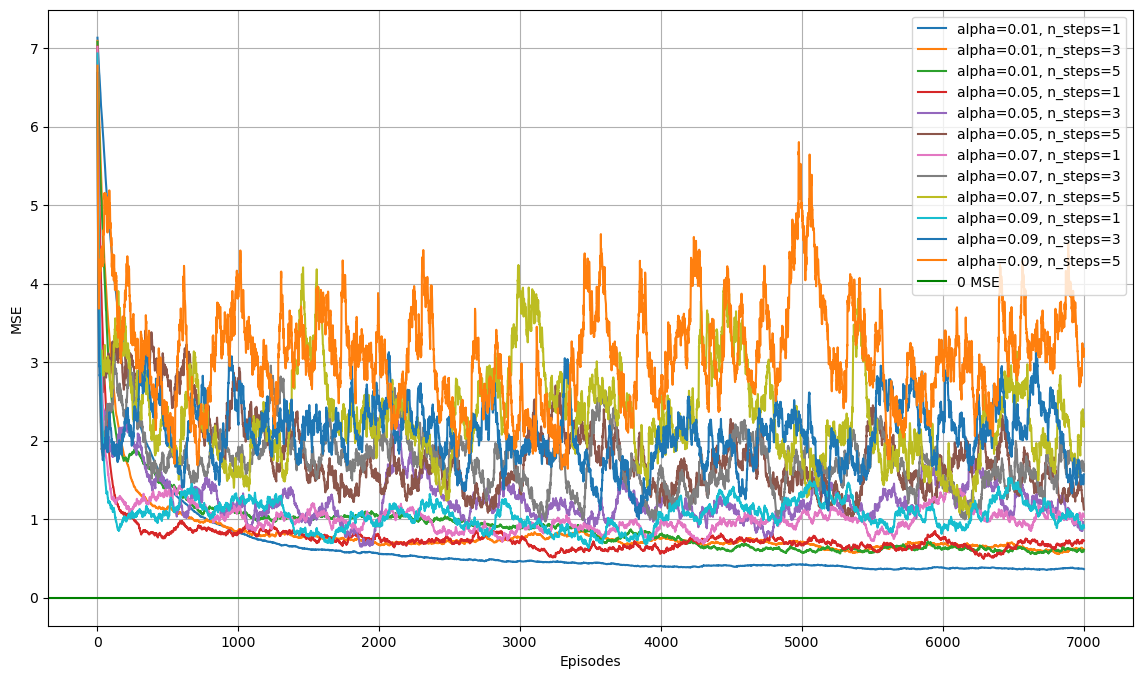

In [14]:
# Plot MSE for each hyperparameter combination
plt.figure(figsize=(14, 8))
for (alpha, n_steps), data in results.items():
    episodes = np.arange(1, data["mean_mse"].shape[0] + 1)
    plt.plot(episodes, data["mean_mse"], label=f"alpha={alpha}, n_steps={n_steps}")
plt.axhline(y=0, color='g', label='0 MSE')
plt.xlabel("Episodes")
plt.ylabel("MSE")
plt.grid(True)
plt.legend()
plt.show()

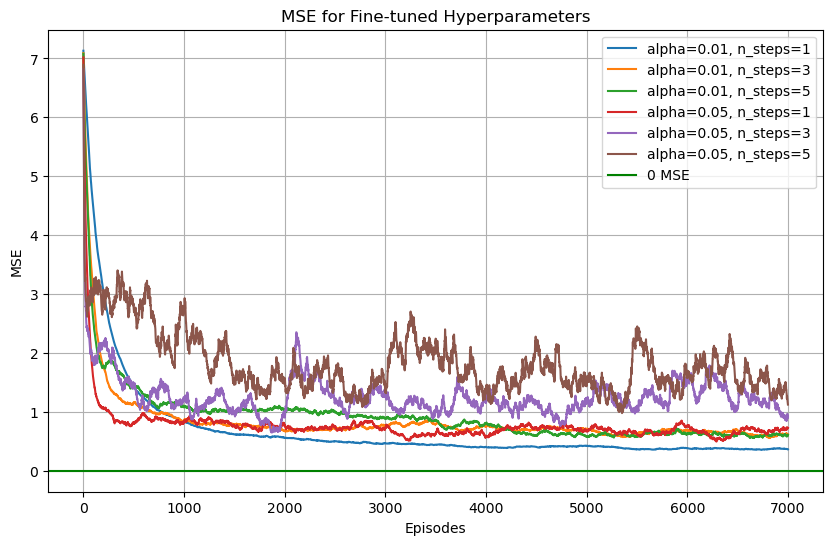

In [15]:
# Considering only alpha=0.01, 0.05 and n_steps=1, 3, 5
alpha_vals_fine = [0.01, 0.05]
n_steps_vals_fine = [1, 3, 5]
# Plotting MSE for fine-tuned hyperparameters
plt.figure(figsize=(10, 6))
for (alpha, n_steps), data in results.items():
    if alpha in alpha_vals_fine and n_steps in n_steps_vals_fine:
        episodes = np.arange(1, data["mean_mse"].shape[0] + 1)
        plt.plot(episodes, data["mean_mse"], label=f"alpha={alpha}, n_steps={n_steps}")
plt.axhline(y=0, color='g', label='0 MSE')
plt.xlabel("Episodes")
plt.ylabel("MSE")
plt.title("MSE for Fine-tuned Hyperparameters")
plt.grid(True)
plt.legend()
plt.show()

### Plotting Mean Steps

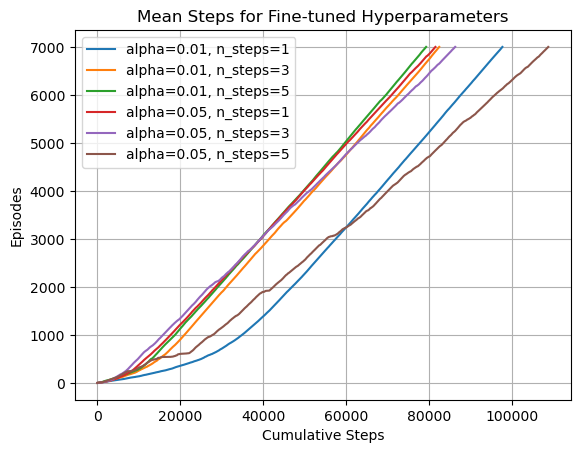

In [16]:
alpha_vals_fine = [0.01, 0.05]
n_steps_vals_fine = [1, 3, 5]
hp_combos_fine = list(product(alpha_vals_fine, n_steps_vals_fine))
# Plotting MSE for fine-tuned hyperparameters
for alpha, n_steps in hp_combos_fine:
    if (alpha, n_steps) in results:
        data = results[(alpha, n_steps)]
        episodes = np.arange(1, data["mean_steps"].shape[0] + 1)
        plt.plot(data["mean_steps"], episodes, label=f"alpha={alpha}, n_steps={n_steps}")
plt.xlabel("Cumulative Steps")
plt.ylabel("Episodes")
plt.title("Mean Steps for Fine-tuned Hyperparameters")
plt.grid(True)
plt.legend()
plt.show()

In [17]:
best_alpha, best_n_steps = min(results.keys(), key=lambda k: np.mean(results[k]["mean_mse"]))
print(f"Best hyperparameters: alpha={best_alpha}, n_steps={best_n_steps}")

Best hyperparameters: alpha=0.01, n_steps=1


In [18]:
# Testing epsilon values
epsilon_values = [0.1, 0.3, 0.7, 0.9, 1.0]
cvm = CatsVMonstersMDP()
results_eps = {}
for epsilon in tqdm(epsilon_values, desc="Running for different epsilon values"):
    print(f"Running for epsilon={epsilon}")
    config = Config(q_init_choice='zeroes', epsilon=epsilon)
    sarsa = SGNStepSARSA(cvm, optimal_vf=optimal_vf, gamma=0.925, config=config)
    points_metadata, mse_metadata, _ = sarsa.run_n_times(num_times=10, num_episodes=7000, alpha=0.005, n_steps=best_n_steps)
    mean_steps = np.mean(points_metadata, axis=0)
    mean_mse = np.mean(mse_metadata, axis=0)
    results_eps[epsilon] = {
        "mean_steps": mean_steps,
        "mean_mse": mean_mse
    }

Running for different epsilon values:   0%|          | 0/5 [00:00<?, ?it/s]

Running for epsilon=0.1


10 Independent Runs:   0%|          | 0/10 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/7000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/7000 [00:00<?, ?it/s]

...

Running SARSA Episodes:   0%|          | 0/7000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/7000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/7000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/7000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/7000 [00:00<?, ?it/s]

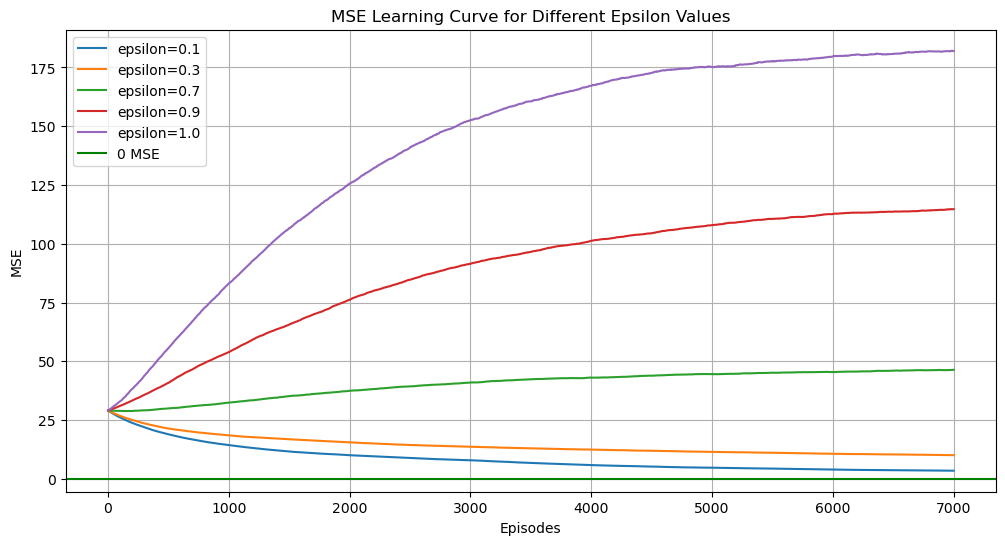

In [19]:
# Plotting the results
plt.figure(figsize=(12, 6))
for epsilon, data in results_eps.items():
    episodes = np.arange(1, data["mean_mse"].shape[0] + 1)
    plt.plot(episodes, data["mean_mse"], label=f"epsilon={epsilon}")
plt.axhline(y=0, color='g', label='0 MSE')
plt.xlabel("Episodes")
plt.ylabel("MSE")
plt.title("MSE Learning Curve for Different Epsilon Values")
plt.grid(True)
plt.legend()
plt.show()

20 Independent Runs:   0%|          | 0/20 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

...

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

Mean Steps: (10000,), Mean MSE: (10000,)


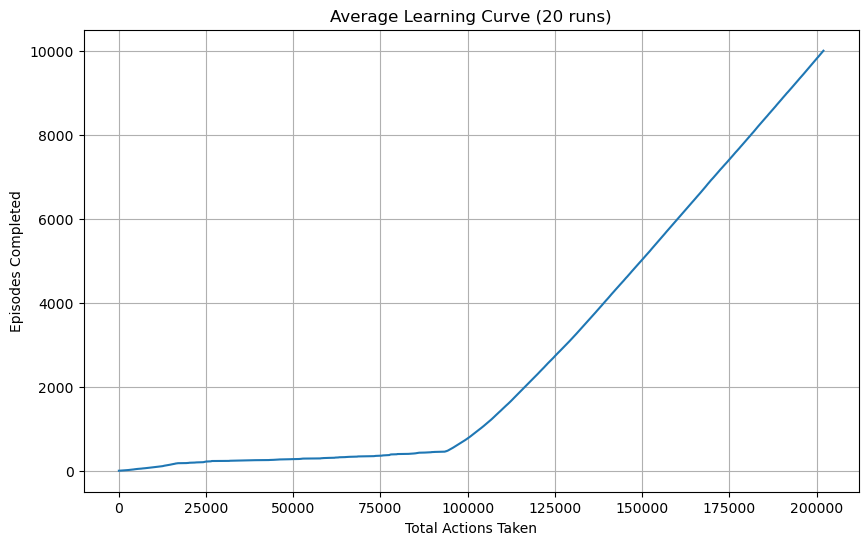

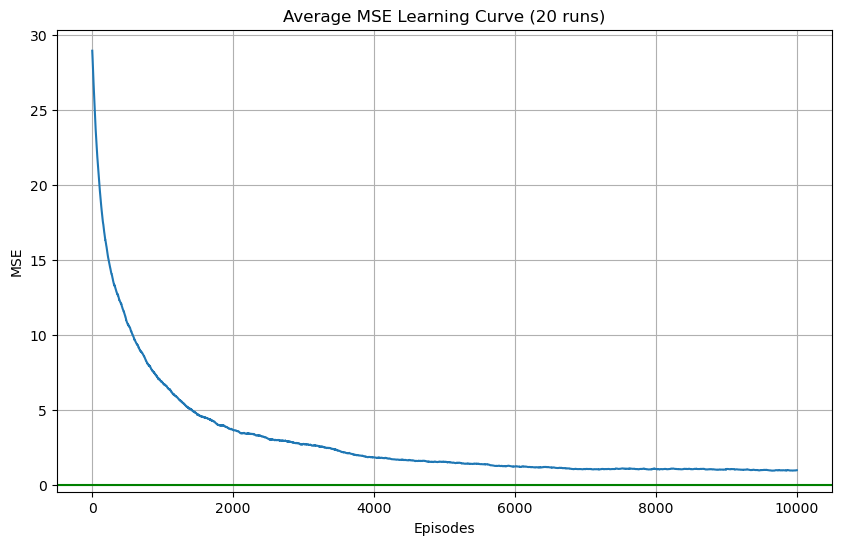

In [20]:
config = Config(q_init_choice='zeroes', epsilon=0.1)
sarsa = SGNStepSARSA(cvm, optimal_vf=optimal_vf, gamma=0.925, config=config)
points_metadata, mse_metadata, vf_data = sarsa.run_n_times(num_times=20, num_episodes=10000, alpha=0.01, n_steps=3)
mean_steps = np.mean(points_metadata, axis=0)
mean_mse = np.mean(mse_metadata, axis=0)
print(f"Mean Steps: {mean_steps.shape}, Mean MSE: {mean_mse.shape}")
plt.figure(figsize=(10, 6))
episodes = np.arange(1, mean_steps.shape[0] + 1)
plt.plot(mean_steps, episodes)
plt.xlabel("Total Actions Taken")
plt.ylabel("Episodes Completed")
plt.title("Average Learning Curve (20 runs)")
plt.grid(True)
plt.show()
plt.figure(figsize=(10, 6))
episodes = np.arange(1, mean_mse.shape[0] + 1)
plt.plot(episodes, mean_mse)
plt.axhline(y=0, color='g', label='0 MSE')
plt.xlabel("Episodes")
plt.ylabel("MSE")
plt.title("Average MSE Learning Curve (20 runs)")
plt.grid(True)
plt.show()

In [21]:
print(vf_data.shape)
average_vf = {}
for vf in vf_data:
    for state in vf:
        if state in average_vf:
            average_vf[state] += vf[state]
        else:
            average_vf[state] = vf[state]

for state in average_vf:
    average_vf[state] /= vf_data.shape[0]

display_value_function(optimal_mdp, average_vf)
max_error = max_norm_error(average_vf, optimal_vf)
print(f'Max norm error: {max_error}')

(20,)
1.6801	1.8385	1.5901	2.4343	3.7330	
1.9925	2.5385	3.0756	3.8837	6.6047	
1.6508	0.0000	0.0000	0.0000	8.1668	
1.0824	-0.0707	0.0000	8.1810	9.3544	
-0.1508	3.5711	7.5070	9.0571	0.0000	
Max norm error: 1.3754259793134773


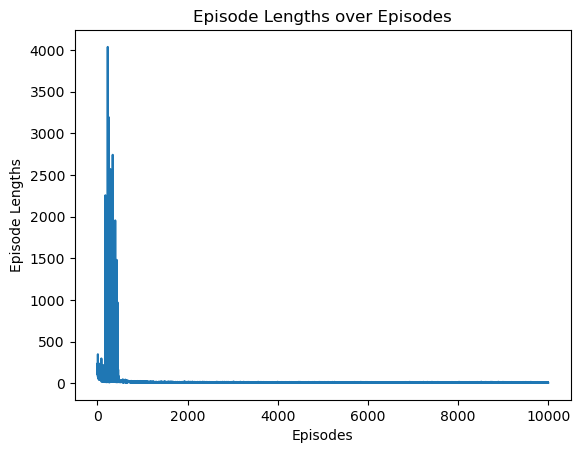

In [22]:
episode_lengths = np.diff(mean_steps)
plt.plot(episode_lengths)
plt.xlabel("Episodes")
plt.ylabel("Episode Lengths")
plt.title("Episode Lengths over Episodes")
plt.show()

In [23]:
policy = sarsa.get_greedy_policy()
display_policy(optimal_mdp, policy)

↓	←	←	↓	↓	
→	→	→	→	↓	
↑	X	X	X	↓	
↑	←	X	→	↓	
←	→	→	→	G	


In [24]:
rw_metadata = sarsa.run_n_times(num_times=10, num_episodes=5000, alpha=0.01, n_steps=3, get_reward_metadata=True)

10 Independent Runs:   0%|          | 0/10 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

...

Running SARSA Episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

(10, 5000)
(5000,)


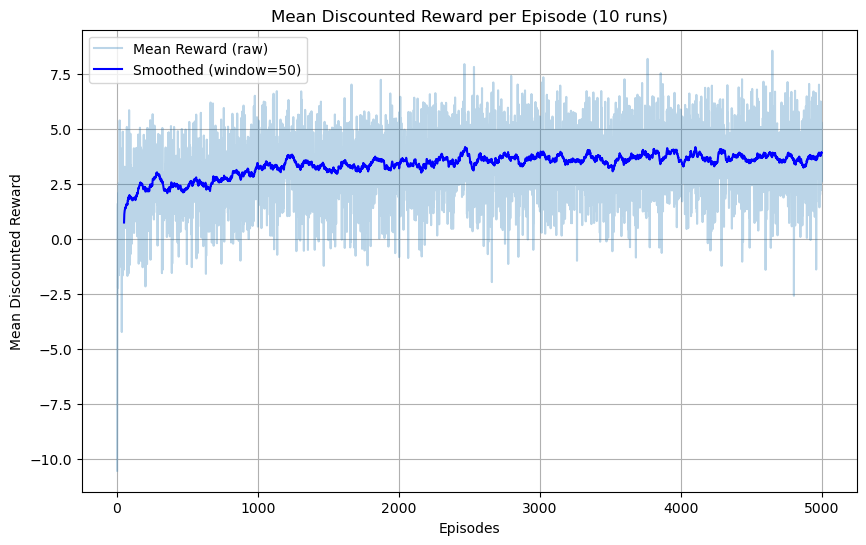

In [32]:
print(rw_metadata.shape)

# rw_metadata shape should be (num_runs, num_episodes)
mean_rewards = np.mean(rw_metadata, axis=0)
print(mean_rewards.shape)

# smoothing window
window = 50
kernel = np.ones(window) / window
smoothed_mean_rewards = np.convolve(mean_rewards, kernel, mode='valid')

# Episode indices
episodes_raw = np.arange(1, len(mean_rewards) + 1)                     # full length
episodes_smooth = np.arange(window, len(mean_rewards) + 1)             # aligned with 'valid'

plt.figure(figsize=(10, 6))

# Plot raw rewards
plt.plot(episodes_raw, mean_rewards, alpha=0.3, label="Mean Reward (raw)")

# Plot smoothed rewards
plt.plot(episodes_smooth, smoothed_mean_rewards, color='blue', label=f"Smoothed (window={window})")

plt.xlabel("Episodes")
plt.ylabel("Mean Discounted Reward")
plt.title("Mean Discounted Reward per Episode (10 runs)")
plt.grid(True)
plt.legend()
plt.show()
